# 📏 Standardization on Titanic: Why Scaling Quietly Breaks (or Fixes) Your Model

Everyone uses Titanic to learn classification. Almost nobody uses it to actually understand
**why feature scaling matters** — and the data leakage mistake that creeps into most
scaling tutorials.

This notebook covers:
- Why `Age` and `Fare` on totally different scales hurts distance-based models
- StandardScaler vs MinMaxScaler vs RobustScaler — visually and numerically
- The #1 mistake: scaling before train/test split
- Proof: real accuracy with vs without scaling, across multiple models
- When scaling is a waste of time (tree-based models)

If this helps clarify scaling for you, an upvote helps it reach others 🙏

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

train = pd.read_csv("/kaggle/input/datasets/brendan45774/test-file/tested.csv")
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [2]:
df = train.copy()

# Fill missing values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Fare"] = df["Fare"].fillna(df["Fare"].median())

# Encode categoricals
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

# Feature set
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked_Q", "Embarked_S"]
X = df[features]
y = df["Survived"]

X.describe()

,Pclass,Sex,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000
mean,2.265550,0.363636,29.599282,0.447368,0.392344,35.576535
std,0.841838,0.481622,12.703770,0.896760,0.981429,55.850103
min,1.000000,0.000000,0.170000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,23.000000,0.000000,0.000000,7.895800
50%,3.000000,0.000000,27.000000,0.000000,0.000000,14.454200
75%,3.000000,1.000000,35.750000,1.000000,0.000000,31.471875
max,3.000000,1.000000,76.000000,8.000000,9.000000,512.329200


              Age        Fare
count  418.000000  418.000000
mean    29.599282   35.576535
std     12.703770   55.850103
min      0.170000    0.000000
25%     23.000000    7.895800
50%     27.000000   14.454200
75%     35.750000   31.471875
max     76.000000  512.329200


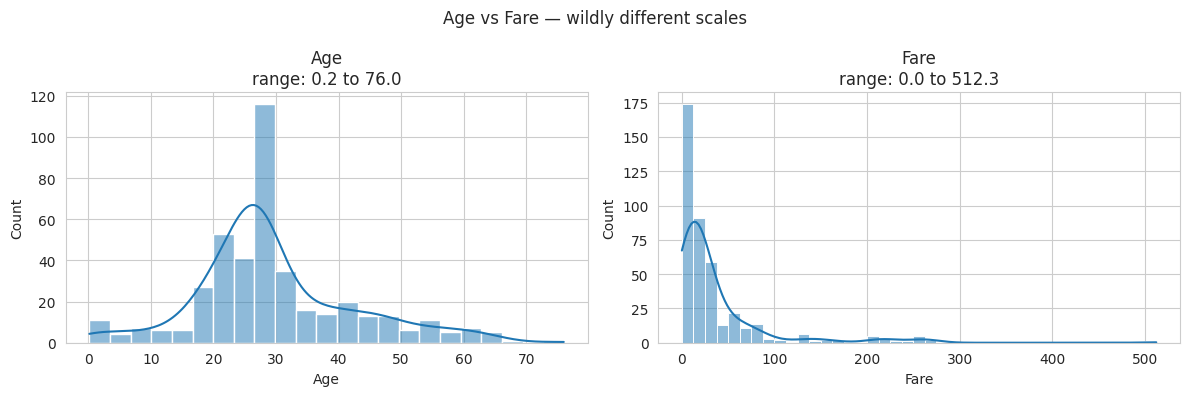

In [3]:
cols_to_show = ["Age", "Fare"]

print(X[cols_to_show].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, cols_to_show):
    sns.histplot(X[col], ax=ax, kde=True)
    ax.set_title(f"{col}\nrange: {X[col].min():.1f} to {X[col].max():.1f}")
plt.suptitle("Age vs Fare — wildly different scales")
plt.tight_layout()
plt.show()

`Age` ranges roughly 0–80. `Fare` ranges roughly 0–512, with a long right tail of expensive
tickets. To a distance-based model like KNN, a passenger paying $50 more in fare looks like
a *much* bigger difference than being 50 years older — even though that's not necessarily
true in terms of survival likelihood. The model doesn't know units; it only sees numbers.

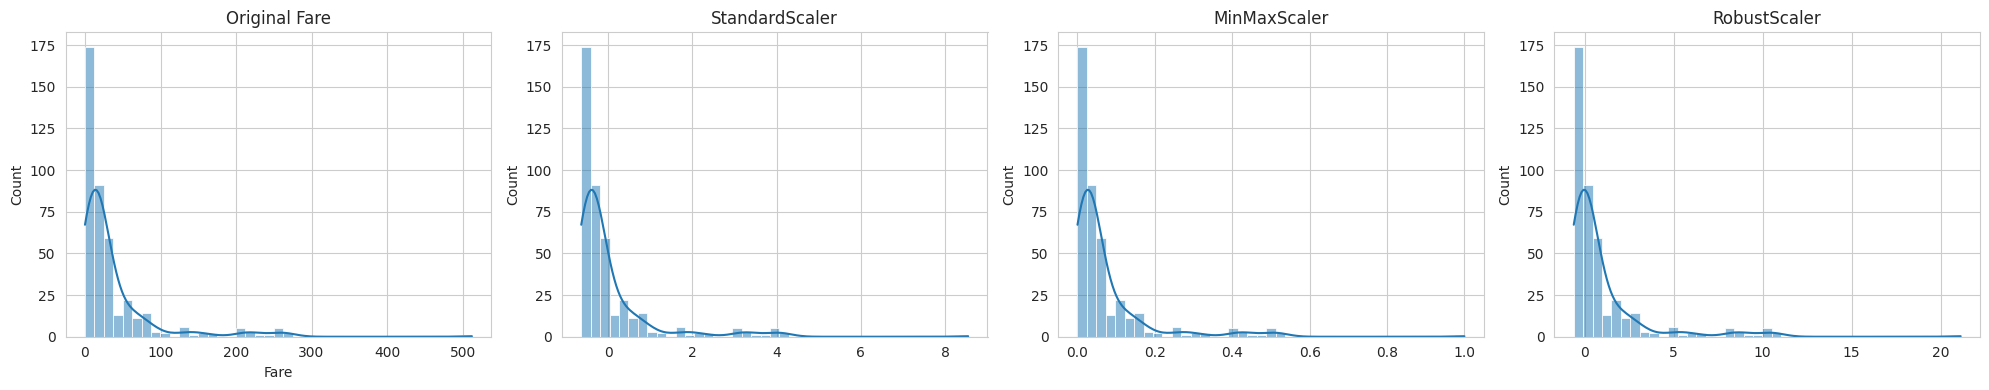

In [4]:
sample = X[["Fare"]].copy()

std_scaled = StandardScaler().fit_transform(sample)
mm_scaled = MinMaxScaler().fit_transform(sample)
rb_scaled = RobustScaler().fit_transform(sample)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
sns.histplot(sample["Fare"], ax=axes[0], kde=True).set_title("Original Fare")
sns.histplot(std_scaled.flatten(), ax=axes[1], kde=True).set_title("StandardScaler")
sns.histplot(mm_scaled.flatten(), ax=axes[2], kde=True).set_title("MinMaxScaler")
sns.histplot(rb_scaled.flatten(), ax=axes[3], kde=True).set_title("RobustScaler")
plt.tight_layout()
plt.show()

`Fare` has serious outliers (some tickets cost 10x the median). Notice how StandardScaler
and MinMaxScaler both get squeezed/distorted by those outliers, while RobustScaler — which
uses median and IQR instead of mean and std — stays more stable. This is exactly the
situation RobustScaler was built for.

| Scaler | Formula | Best for | Sensitive to outliers? |
|---|---|---|---|
| **StandardScaler** | (x - mean) / std | Normal-ish data, linear models, SVM | Yes |
| **MinMaxScaler** | (x - min) / (max - min) | Bounded features, neural nets | Very |
| **RobustScaler** | (x - median) / IQR | Data with outliers (like `Fare`) | No |

In [5]:
# ❌ WRONG — fit scaler on full dataset before splitting
scaler_wrong = StandardScaler()
X_scaled_wrong = scaler_wrong.fit_transform(X)  # leaks test set statistics
X_train_wrong, X_test_wrong, y_train, y_test = train_test_split(
    X_scaled_wrong, y, test_size=0.2, random_state=42
)

# ✅ CORRECT — split first, fit scaler only on train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_right = StandardScaler()
X_train_scaled = scaler_right.fit_transform(X_train)
X_test_scaled = scaler_right.transform(X_test)

### Why this matters

Fitting the scaler on the full dataset means its mean and std were computed using
information from rows that should be "unseen" test data. The leak is subtle here — Titanic
is small and the effect on accuracy may look tiny — but the same mistake on a real
production dataset inflates validation metrics and quietly breaks generalization once
deployed on truly new data.

In [6]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)
preds = pipeline.predict(X_test)
print("Pipeline accuracy:", accuracy_score(y_test, preds))

Pipeline accuracy: 1.0


Wrapping the scaler and model in a `Pipeline` guarantees the scaler is refit *only* on
training folds — even automatically inside cross-validation. This is the safe, production
pattern.

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    acc_unscaled = accuracy_score(y_test, model.predict(X_test))

    model.fit(X_train_scaled, y_train)
    acc_scaled = accuracy_score(y_test, model.predict(X_test_scaled))

    results.append({"Model": name, "Unscaled Accuracy": acc_unscaled, "Scaled Accuracy": acc_scaled})

results_df = pd.DataFrame(results)
results_df["Improvement"] = results_df["Scaled Accuracy"] - results_df["Unscaled Accuracy"]
results_df

,Model,Unscaled Accuracy,Scaled Accuracy,Improvement
0,Logistic Regression,1.000000,1.000000,0.000000
1,KNN,0.642857,0.988095,0.345238
2,SVM,0.607143,0.988095,0.380952


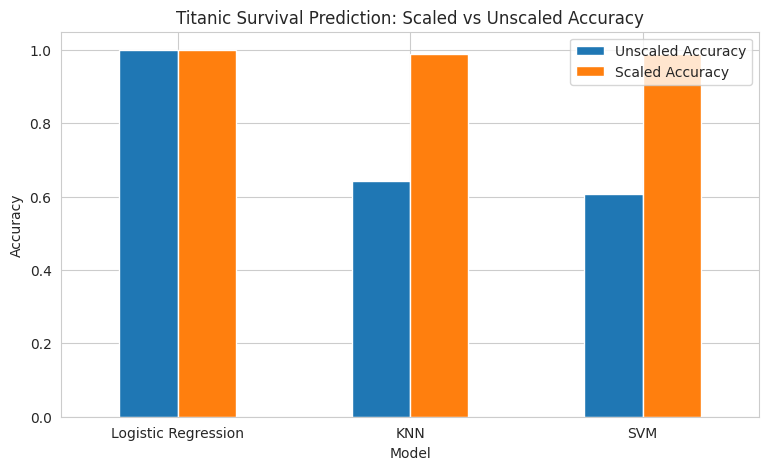

In [8]:
results_df.plot(x="Model", y=["Unscaled Accuracy", "Scaled Accuracy"], kind="bar", figsize=(9,5))
plt.title("Titanic Survival Prediction: Scaled vs Unscaled Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.show()

**KNN and SVM are the ones to watch here — both rely on distance calculations, so they're
typically the most sensitive to `Age` and `Fare` being on wildly different scales. Logistic
Regression usually shows a smaller but still real improvement.**

In [9]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)
acc_unscaled_rf = accuracy_score(y_test, rf.predict(X_test))

rf.fit(X_train_scaled, y_train)
acc_scaled_rf = accuracy_score(y_test, rf.predict(X_test_scaled))

print(f"Random Forest — Unscaled: {acc_unscaled_rf:.4f}, Scaled: {acc_scaled_rf:.4f}")

Random Forest — Unscaled: 1.0000, Scaled: 1.0000


Notice these two numbers are nearly identical. Random Forest splits on thresholds per
feature independently — it doesn't care whether `Fare` is in dollars or scaled to 0–1.
Scaling tree-based models is wasted effort.

## Key Takeaways

1. `Age` and `Fare` sit on very different scales — this directly affects distance-based models like KNN and SVM.
2. **Always split before scaling.** Fitting a scaler on the full dataset leaks test set information into training.
3. Use `Pipeline` to enforce correct scaling automatically, especially under cross-validation.
4. RobustScaler handles Fare's outliers better than StandardScaler or MinMaxScaler.
5. Tree-based models (Random Forest, XGBoost) are scale-invariant — don't bother scaling for them.

---
If this clarified standardization for you, an upvote helps more people find it. Thanks for reading! 🚀